# Decision Tree and Random Forest - CICIDS2017

**Team member:** Kelechi Uko

**Algorithms:** Decision Tree (DT), Random Forest (RF)

This notebook covers the full training process for DT and RF on the CICIDS2017 dataset. It follows the assignment requirements: feature selection, preprocessing (scaling, SMOTE, PCA, LDA), hyperparameter tuning via GridSearchCV, and evaluation on training, validation, and test sets.

Data is loaded using the shared `data_split.py` module from the repo root to guarantee the 60/20/20 split is identical across all group members.

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Import shared data split module from repo root
# This notebook lives in training/ so we go one level up
sys.path.append('..')
from data_split import load_and_split_data, RANDOM_STATE

print("Imports done. RANDOM_STATE:", RANDOM_STATE)

Imports done. RANDOM_STATE: 42


## 2. Load data

Place `cicids2017_cleaned.csv` in the `data/` folder at the repo root. See `data/README.md` for download instructions.

In [2]:
CSV_PATH = "../data/cicids2017_cleaned.csv"

X_train, X_val, X_test, y_train, y_val, y_test = load_and_split_data(CSV_PATH, max_rows=100000)

print(f"\nX_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

Loading data from ../data/cicids2017_cleaned.csv...
Loaded 100000 rows
Target column: Attack Type
Features: 52 columns
Target distribution:
Attack Type
Normal Traffic    83081
DoS                7673
DDoS               5115
Port Scanning      3574
Brute Force         377
Web Attacks          92
Bots                 88
Name: count, dtype: int64

Train:      60000 rows (60%)
Validation: 20000 rows (20%)
Test:       20000 rows (20%)

X_train: (60000, 52), X_val: (20000, 52), X_test: (20000, 52)


## 3. Feature selection

The full dataset has 52 features. Training on all of them makes GridSearchCV very slow and risks memory issues. Based on the CICIDS2017 paper (Sharafaldin et al.), the most informative features for network attack detection are flow-level statistics.

The 10 features below cover packet size, timing, flag activity, and byte/packet rates. They are consistently highlighted as the most discriminative in the literature.

In [3]:
SELECTED_FEATURES = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Length of Fwd Packets",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Flow IAT Mean",
    "Packet Length Mean",
    "PSH Flag Count",
]

missing = [f for f in SELECTED_FEATURES if f not in X_train.columns]
if missing:
    print(f"WARNING - features not found: {missing}")
else:
    print("All selected features present in dataset.")

X_train_s = X_train[SELECTED_FEATURES]
X_val_s   = X_val[SELECTED_FEATURES]
X_test_s  = X_test[SELECTED_FEATURES]

print(f"Feature set shape: {X_train_s.shape}")

All selected features present in dataset.
Feature set shape: (60000, 10)


## 4. Helper functions

The evaluate_model function reports training accuracy, validation/test accuracy, recall, and F1 in every run. Recall is tracked specifically because it is the key metric for comparing SMOTE vs no SMOTE runs.

In [4]:
results_log = []


def evaluate_model(name, model, X_tr, y_tr, X_ev, y_ev, label="val"):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    train_acc = accuracy_score(y_tr, model.predict(X_tr))

    y_pred = model.predict(X_ev)
    acc = accuracy_score(y_ev, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_ev, y_pred, average="weighted", zero_division=0
    )

    print(f"\n=== {name} ===")
    print(f"Train accuracy:        {train_acc:.4f}")
    print(f"{label.capitalize()} accuracy:  {acc:.4f}")
    print(f"{label.capitalize()} recall:    {rec:.4f}")
    print(f"{label.capitalize()} F1:        {f1:.4f}")
    print(f"Training time:         {elapsed:.1f}s")
    print(classification_report(y_ev, y_pred, zero_division=0))

    results_log.append({
        "model": name,
        "eval_set": label,
        "train_accuracy": train_acc,
        "accuracy": acc,
        "precision_weighted": prec,
        "recall_weighted": rec,
        "f1_weighted": f1,
        "train_time_s": elapsed,
    })

    return model, y_pred


def plot_confusion(y_true, y_pred, title):
    fig, ax = plt.subplots(figsize=(7, 5))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


print("Helper functions ready.")

Helper functions ready.


---
## DECISION TREE

Decision Trees split data based on feature thresholds, so scaling has no effect on their performance. Polynomial features are also not applied since trees already capture non-linear boundaries through splits. The main levers are depth control, split criteria, and handling class imbalance via SMOTE or class_weight.

## 5. Decision Tree - baseline


=== DT - baseline ===
Train accuracy:        0.9991
Val accuracy:  0.9939
Val recall:    0.9939
Val F1:        0.9938
Training time:         0.4s
                precision    recall  f1-score   support

          Bots       0.83      0.59      0.69        17
   Brute Force       0.99      0.92      0.95        76
          DDoS       1.00      1.00      1.00      1023
           DoS       0.98      0.98      0.98      1534
Normal Traffic       1.00      1.00      1.00     16616
 Port Scanning       0.99      1.00      1.00       715
   Web Attacks       0.07      0.05      0.06        19

      accuracy                           0.99     20000
     macro avg       0.84      0.79      0.81     20000
  weighted avg       0.99      0.99      0.99     20000



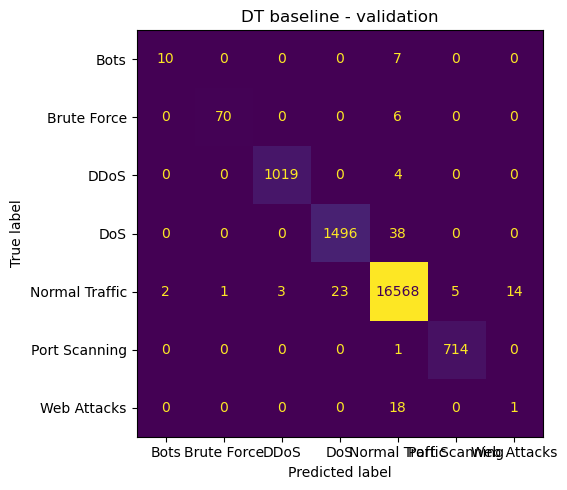

In [5]:
dt_baseline, dt_baseline_pred = evaluate_model(
    "DT - baseline",
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    X_train_s, y_train,
    X_val_s, y_val
)

plot_confusion(y_val, dt_baseline_pred, "DT baseline - validation")

## 6. Decision Tree - with and without SMOTE

Focus on recall for the minority class (Port Scanning). SMOTE should increase minority recall at the potential cost of overall accuracy.


=== DT - with SMOTE ===
Train accuracy:        0.9980
Val accuracy:  0.9866
Val recall:    0.9866
Val F1:        0.9889
Training time:         2.0s
                precision    recall  f1-score   support

          Bots       0.32      0.65      0.43        17
   Brute Force       0.91      0.93      0.92        76
          DDoS       1.00      1.00      1.00      1023
           DoS       0.95      0.98      0.97      1534
Normal Traffic       1.00      0.99      0.99     16616
 Port Scanning       0.99      1.00      1.00       715
   Web Attacks       0.13      0.84      0.22        19

      accuracy                           0.99     20000
     macro avg       0.76      0.91      0.79     20000
  weighted avg       0.99      0.99      0.99     20000



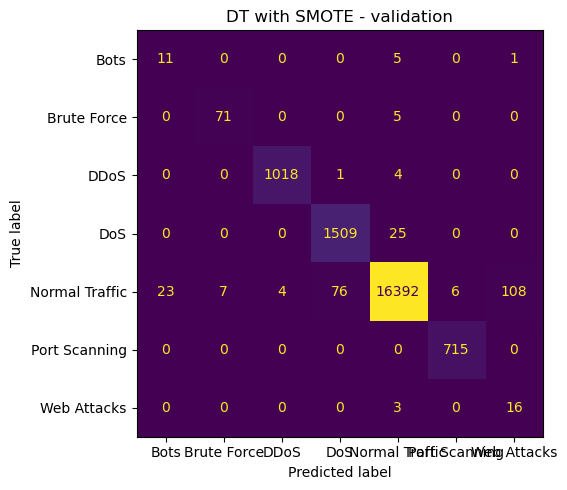

In [6]:
dt_smote, dt_smote_pred = evaluate_model(
    "DT - with SMOTE",
    ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),
    X_train_s, y_train,
    X_val_s, y_val
)

plot_confusion(y_val, dt_smote_pred, "DT with SMOTE - validation")

## 7. Decision Tree - PCA and LDA

Scaling is applied before PCA and LDA since both are sensitive to feature magnitude. LDA reduces to at most n_classes - 1 dimensions, which is 1 dimension for this binary problem.


=== DT - StandardScaler + PCA(0.95) ===
Train accuracy:        0.9991
Val accuracy:  0.9898
Val recall:    0.9898
Val F1:        0.9896
Training time:         0.7s
                precision    recall  f1-score   support

          Bots       1.00      0.59      0.74        17
   Brute Force       0.97      0.84      0.90        76
          DDoS       0.99      0.99      0.99      1023
           DoS       0.96      0.96      0.96      1534
Normal Traffic       0.99      0.99      0.99     16616
 Port Scanning       0.99      1.00      0.99       715
   Web Attacks       0.06      0.05      0.06        19

      accuracy                           0.99     20000
     macro avg       0.85      0.77      0.80     20000
  weighted avg       0.99      0.99      0.99     20000



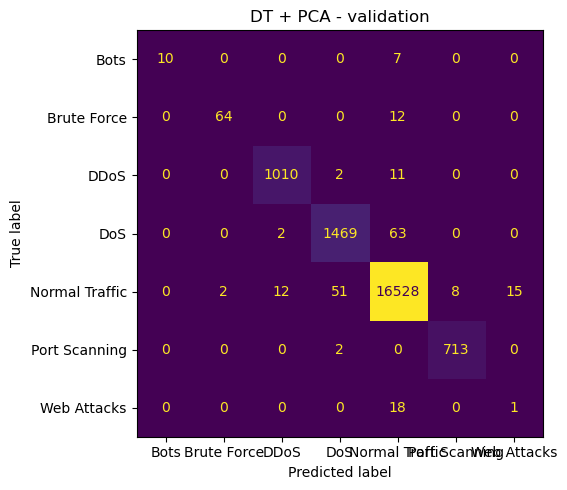

In [7]:
# StandardScaler + PCA
dt_pca, dt_pca_pred = evaluate_model(
    "DT - StandardScaler + PCA(0.95)",
    Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
        ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),
    X_train_s, y_train,
    X_val_s, y_val
)
plot_confusion(y_val, dt_pca_pred, "DT + PCA - validation")


=== DT - StandardScaler + LDA ===
Train accuracy:        0.9991
Val accuracy:  0.9894
Val recall:    0.9894
Val F1:        0.9893
Training time:         0.7s
                precision    recall  f1-score   support

          Bots       1.00      0.47      0.64        17
   Brute Force       0.95      0.83      0.89        76
          DDoS       0.98      0.98      0.98      1023
           DoS       0.96      0.96      0.96      1534
Normal Traffic       0.99      0.99      0.99     16616
 Port Scanning       0.98      1.00      0.99       715
   Web Attacks       0.05      0.05      0.05        19

      accuracy                           0.99     20000
     macro avg       0.85      0.76      0.79     20000
  weighted avg       0.99      0.99      0.99     20000



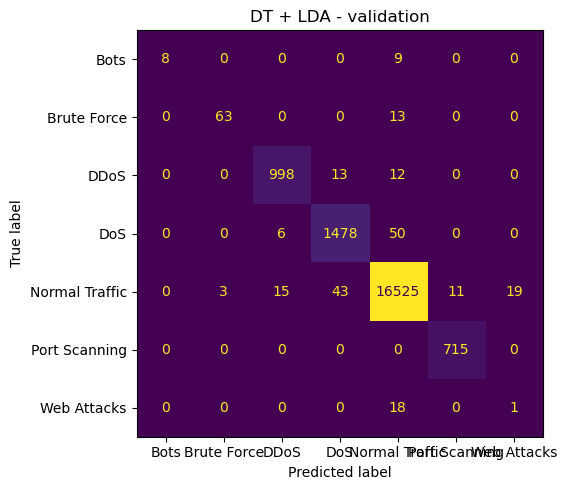

In [8]:
# StandardScaler + LDA
dt_lda, dt_lda_pred = evaluate_model(
    "DT - StandardScaler + LDA",
    Pipeline([
        ("scaler", StandardScaler()),
        ("lda", LDA()),
        ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),
    X_train_s, y_train,
    X_val_s, y_val
)
plot_confusion(y_val, dt_lda_pred, "DT + LDA - validation")

## 8. Decision Tree - GridSearchCV

Systematic search over depth, split threshold, and splitting criterion. 3-fold cross-validation, scoring on weighted F1.

Fitting 3 folds for each of 24 candidates, totalling 72 fits

=== DT - GridSearchCV best ===
Train accuracy:        0.9982
Val accuracy:  0.9945
Val recall:    0.9945
Val F1:        0.9941
Training time:         6.6s
                precision    recall  f1-score   support

          Bots       1.00      0.59      0.74        17
   Brute Force       0.99      0.88      0.93        76
          DDoS       1.00      1.00      1.00      1023
           DoS       0.99      0.98      0.98      1534
Normal Traffic       1.00      1.00      1.00     16616
 Port Scanning       0.99      1.00      1.00       715
   Web Attacks       0.00      0.00      0.00        19

      accuracy                           0.99     20000
     macro avg       0.85      0.78      0.81     20000
  weighted avg       0.99      0.99      0.99     20000

Best DT params: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 2}


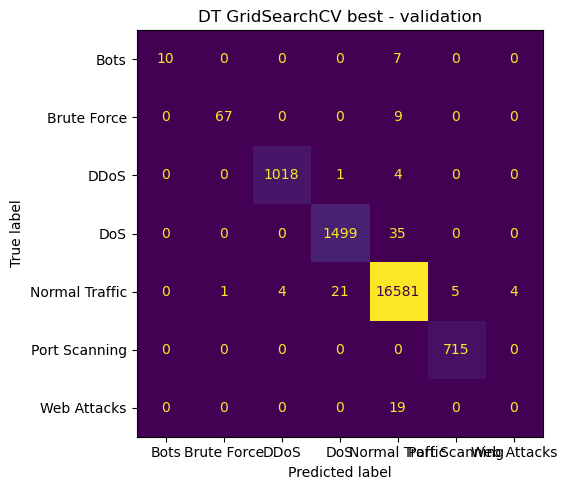

In [9]:
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid={
        "max_depth": [5, 10, 20, None],
        "min_samples_split": [2, 10, 50],
        "criterion": ["gini", "entropy"]
    },
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

dt_best, dt_best_pred = evaluate_model(
    "DT - GridSearchCV best",
    dt_grid,
    X_train_s, y_train,
    X_val_s, y_val
)

print("Best DT params:", dt_grid.best_params_)
plot_confusion(y_val, dt_best_pred, "DT GridSearchCV best - validation")

---
## RANDOM FOREST

Random Forest builds many decision trees on random subsets of data and features and averages their predictions. It is more robust to overfitting than a single DT. Like DT, it does not need feature scaling, but we test it anyway to confirm and report the finding as the assignment requires.

## 9. Random Forest - baseline


=== RF - baseline, 100 trees ===
Train accuracy:        0.9991
Val accuracy:  0.9947
Val recall:    0.9947
Val F1:        0.9945
Training time:         1.1s
                precision    recall  f1-score   support

          Bots       1.00      0.59      0.74        17
   Brute Force       1.00      0.91      0.95        76
          DDoS       1.00      1.00      1.00      1023
           DoS       0.99      0.98      0.98      1534
Normal Traffic       1.00      1.00      1.00     16616
 Port Scanning       0.99      1.00      1.00       715
   Web Attacks       0.07      0.05      0.06        19

      accuracy                           0.99     20000
     macro avg       0.86      0.79      0.82     20000
  weighted avg       0.99      0.99      0.99     20000



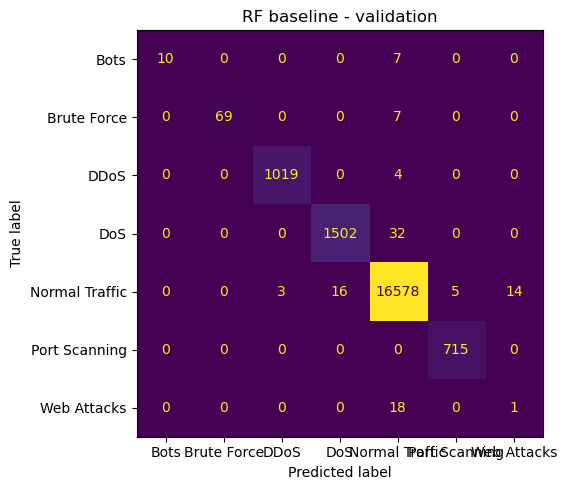

In [10]:
rf_baseline, rf_baseline_pred = evaluate_model(
    "RF - baseline, 100 trees",
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    X_train_s, y_train,
    X_val_s, y_val
)

plot_confusion(y_val, rf_baseline_pred, "RF baseline - validation")

## 10. Random Forest - StandardScaler vs MinMaxScaler

RF does not require scaling. This test confirms that finding and gives us something to report in section 8 of the group notebook.

In [11]:
for scaler_name, scaler in [("StandardScaler", StandardScaler()), ("MinMaxScaler", MinMaxScaler())]:
    evaluate_model(
        f"RF - {scaler_name}",
        Pipeline([
            ("scaler", scaler),
            ("classifier", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
        ]),
        X_train_s, y_train,
        X_val_s, y_val
    )


=== RF - StandardScaler ===
Train accuracy:        0.9991
Val accuracy:  0.9947
Val recall:    0.9947
Val F1:        0.9945
Training time:         1.1s
                precision    recall  f1-score   support

          Bots       1.00      0.59      0.74        17
   Brute Force       1.00      0.92      0.96        76
          DDoS       1.00      1.00      1.00      1023
           DoS       0.99      0.98      0.98      1534
Normal Traffic       1.00      1.00      1.00     16616
 Port Scanning       0.99      1.00      1.00       715
   Web Attacks       0.07      0.05      0.06        19

      accuracy                           0.99     20000
     macro avg       0.86      0.79      0.82     20000
  weighted avg       0.99      0.99      0.99     20000


=== RF - MinMaxScaler ===
Train accuracy:        0.9991
Val accuracy:  0.9947
Val recall:    0.9947
Val F1:        0.9945
Training time:         1.4s
                precision    recall  f1-score   support

          Bots      

## 11. Random Forest - with and without SMOTE


=== RF - with SMOTE ===
Train accuracy:        0.9980
Val accuracy:  0.9888
Val recall:    0.9888
Val F1:        0.9908
Training time:         13.3s
                precision    recall  f1-score   support

          Bots       0.34      0.71      0.46        17
   Brute Force       1.00      0.91      0.95        76
          DDoS       1.00      1.00      1.00      1023
           DoS       0.97      0.99      0.98      1534
Normal Traffic       1.00      0.99      0.99     16616
 Port Scanning       0.99      1.00      1.00       715
   Web Attacks       0.14      0.84      0.24        19

      accuracy                           0.99     20000
     macro avg       0.78      0.92      0.80     20000
  weighted avg       0.99      0.99      0.99     20000



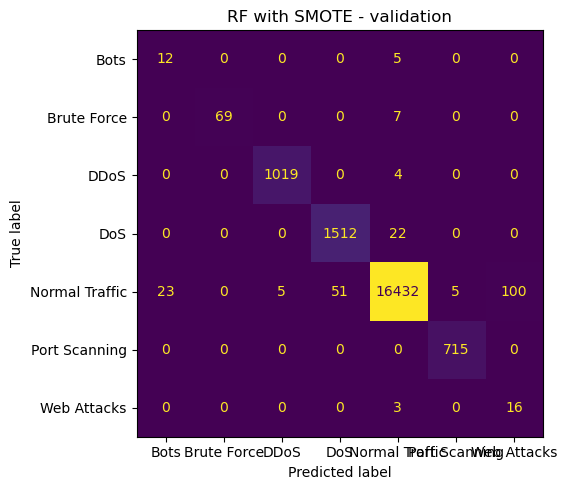

In [12]:
rf_smote, rf_smote_pred = evaluate_model(
    "RF - with SMOTE",
    ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("classifier", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    X_train_s, y_train,
    X_val_s, y_val
)

plot_confusion(y_val, rf_smote_pred, "RF with SMOTE - validation")

## 12. Random Forest - PCA and LDA


=== RF - StandardScaler + PCA(0.95) ===
Train accuracy:        0.9991
Val accuracy:  0.9919
Val recall:    0.9919
Val F1:        0.9917
Training time:         2.4s
                precision    recall  f1-score   support

          Bots       1.00      0.59      0.74        17
   Brute Force       1.00      0.84      0.91        76
          DDoS       0.99      0.99      0.99      1023
           DoS       0.99      0.96      0.97      1534
Normal Traffic       0.99      1.00      1.00     16616
 Port Scanning       0.98      1.00      0.99       715
   Web Attacks       0.07      0.05      0.06        19

      accuracy                           0.99     20000
     macro avg       0.86      0.78      0.81     20000
  weighted avg       0.99      0.99      0.99     20000



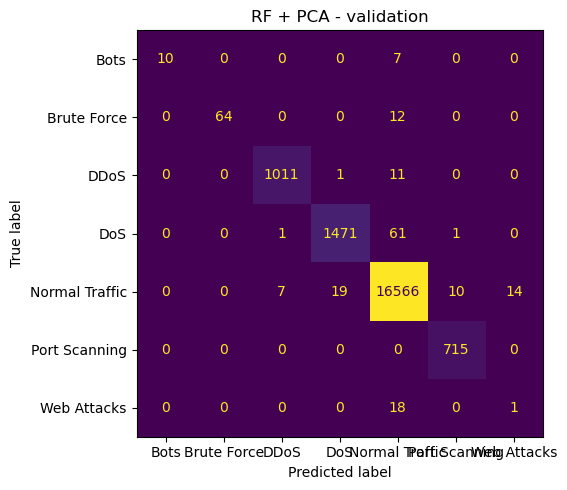

In [13]:
rf_pca, rf_pca_pred = evaluate_model(
    "RF - StandardScaler + PCA(0.95)",
    Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
        ("classifier", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    X_train_s, y_train,
    X_val_s, y_val
)
plot_confusion(y_val, rf_pca_pred, "RF + PCA - validation")


=== RF - StandardScaler + LDA ===
Train accuracy:        0.9991
Val accuracy:  0.9916
Val recall:    0.9916
Val F1:        0.9914
Training time:         2.6s
                precision    recall  f1-score   support

          Bots       1.00      0.47      0.64        17
   Brute Force       1.00      0.82      0.90        76
          DDoS       0.99      0.98      0.99      1023
           DoS       0.98      0.97      0.97      1534
Normal Traffic       0.99      1.00      1.00     16616
 Port Scanning       0.98      1.00      0.99       715
   Web Attacks       0.06      0.05      0.06        19

      accuracy                           0.99     20000
     macro avg       0.86      0.76      0.79     20000
  weighted avg       0.99      0.99      0.99     20000



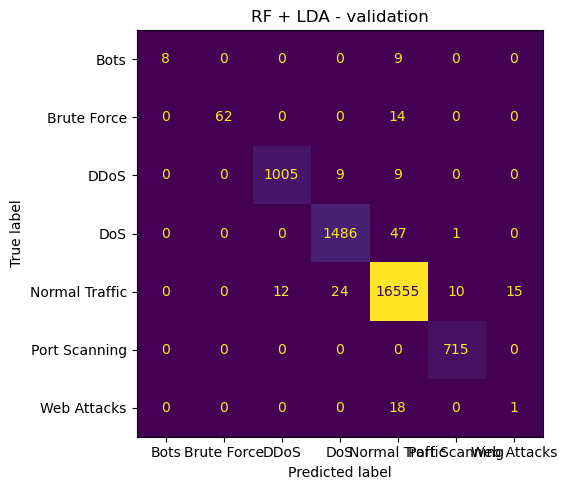

In [14]:
rf_lda, rf_lda_pred = evaluate_model(
    "RF - StandardScaler + LDA",
    Pipeline([
        ("scaler", StandardScaler()),
        ("lda", LDA()),
        ("classifier", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    X_train_s, y_train,
    X_val_s, y_val
)
plot_confusion(y_val, rf_lda_pred, "RF + LDA - validation")

## 13. Random Forest - GridSearchCV

Fitting 3 folds for each of 36 candidates, totalling 108 fits

=== RF - GridSearchCV best ===
Train accuracy:        0.9981
Val accuracy:  0.9953
Val recall:    0.9953
Val F1:        0.9949
Training time:         147.4s
                precision    recall  f1-score   support

          Bots       1.00      0.59      0.74        17
   Brute Force       1.00      0.91      0.95        76
          DDoS       1.00      1.00      1.00      1023
           DoS       0.99      0.98      0.99      1534
Normal Traffic       1.00      1.00      1.00     16616
 Port Scanning       0.99      1.00      1.00       715
   Web Attacks       0.00      0.00      0.00        19

      accuracy                           1.00     20000
     macro avg       0.85      0.78      0.81     20000
  weighted avg       0.99      1.00      0.99     20000

Best RF params: {'class_weight': None, 'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}


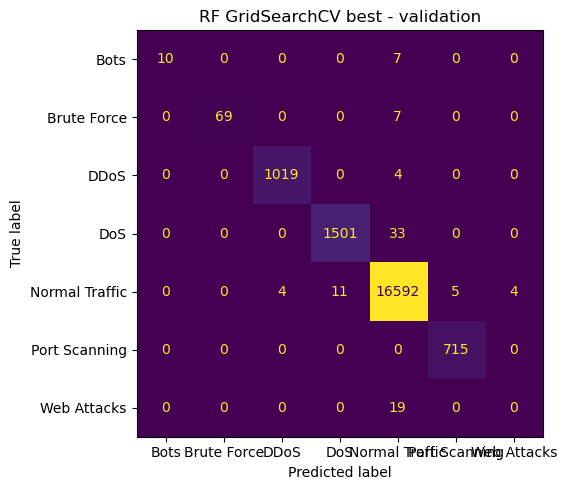

In [15]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid={
        "n_estimators": [50, 100, 200],
        "max_depth": [10, 20, None],
        "min_samples_split": [2, 10],
        "class_weight": [None, "balanced"]
    },
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

rf_best, rf_best_pred = evaluate_model(
    "RF - GridSearchCV best",
    rf_grid,
    X_train_s, y_train,
    X_val_s, y_val
)

print("Best RF params:", rf_grid.best_params_)
plot_confusion(y_val, rf_best_pred, "RF GridSearchCV best - validation")

## 14. Feature importances (Random Forest)

RF provides feature importances out of the box. This is useful evidence for justifying the feature selection choices in the group submission notebook.

                    feature  importance
     Bwd Packet Length Mean    0.234451
Total Length of Fwd Packets    0.147741
         Packet Length Mean    0.138025
          Total Fwd Packets    0.092003
             Flow Packets/s    0.085599
     Fwd Packet Length Mean    0.082517
              Flow IAT Mean    0.064808
              Flow Duration    0.053082
               Flow Bytes/s    0.052290
             PSH Flag Count    0.049484


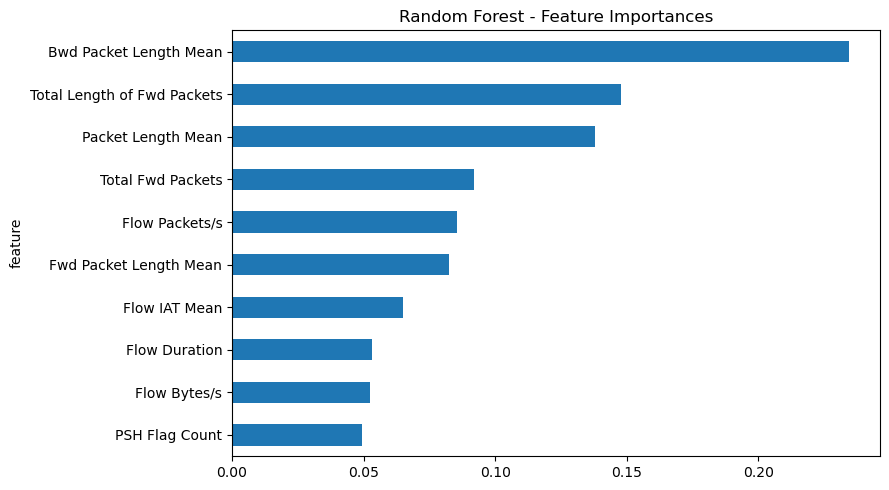

In [16]:
best_rf_estimator = rf_grid.best_estimator_ if hasattr(rf_grid, "best_estimator_") else rf_baseline

importance_df = pd.DataFrame({
    "feature": X_train_s.columns,
    "importance": best_rf_estimator.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
importance_df.plot.barh(x="feature", y="importance", ax=ax, legend=False)
ax.set_title("Random Forest - Feature Importances")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 15. All results summary

In [17]:
results_df = pd.DataFrame(results_log).sort_values("f1_weighted", ascending=False)
print(results_df.to_string(index=False))

                          model eval_set  train_accuracy  accuracy  precision_weighted  recall_weighted  f1_weighted  train_time_s
         RF - GridSearchCV best      val        0.998117   0.99530            0.994553          0.99530     0.994867    147.397423
       RF - baseline, 100 trees      val        0.999083   0.99470            0.994513          0.99470     0.994549      1.072218
              RF - MinMaxScaler      val        0.999083   0.99465            0.994462          0.99465     0.994498      1.395915
            RF - StandardScaler      val        0.999083   0.99465            0.994417          0.99465     0.994477      1.070108
         DT - GridSearchCV best      val        0.998217   0.99450            0.993745          0.99450     0.994063      6.647616
                  DT - baseline      val        0.999083   0.99390            0.993664          0.99390     0.993756      0.357067
RF - StandardScaler + PCA(0.95)      val        0.999083   0.99190            0.991

## 16. Final test set evaluation

The test set is used exactly once, here at the end. Pick the best model from the validation results and evaluate it on the test set. These are the numbers that go into the group submission notebook.

Best model on validation: RF - GridSearchCV best

FINAL TEST SET - RF - GridSearchCV best
Test accuracy: 0.9942
                precision    recall  f1-score   support

          Bots       0.43      0.17      0.24        18
   Brute Force       1.00      0.92      0.96        75
          DDoS       1.00      1.00      1.00      1023
           DoS       0.98      0.98      0.98      1535
Normal Traffic       1.00      1.00      1.00     16616
 Port Scanning       0.99      1.00      0.99       715
   Web Attacks       0.33      0.06      0.10        18

      accuracy                           0.99     20000
     macro avg       0.82      0.73      0.75     20000
  weighted avg       0.99      0.99      0.99     20000



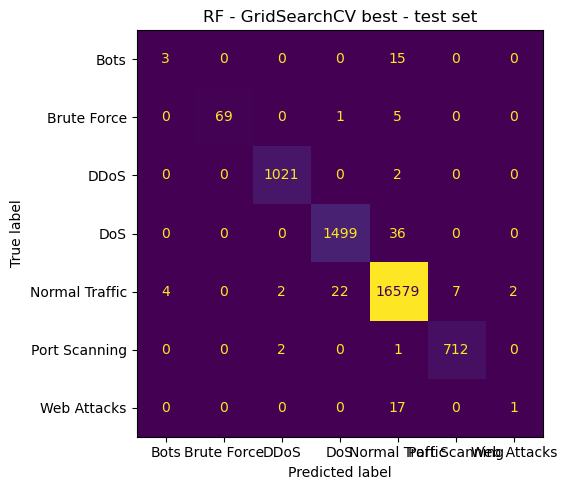

In [18]:
model_map = {
    "DT - baseline": dt_baseline,
    "DT - with SMOTE": dt_smote,
    "DT - StandardScaler + PCA(0.95)": dt_pca,
    "DT - StandardScaler + LDA": dt_lda,
    "DT - GridSearchCV best": dt_best,
    "RF - baseline, 100 trees": rf_baseline,
    "RF - with SMOTE": rf_smote,
    "RF - StandardScaler + PCA(0.95)": rf_pca,
    "RF - StandardScaler + LDA": rf_lda,
    "RF - GridSearchCV best": rf_best,
}

best_name = results_df.iloc[0]["model"]
print(f"Best model on validation: {best_name}")

final_model = model_map.get(best_name, rf_best)
test_pred = final_model.predict(X_test_s)

print(f"\nFINAL TEST SET - {best_name}")
print(f"Test accuracy: {accuracy_score(y_test, test_pred):.4f}")
print(classification_report(y_test, test_pred, zero_division=0))
plot_confusion(y_test, test_pred, f"{best_name} - test set")